<h1 align=center style="line-height:300%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
سری سوم تمارین عملی درس داده کاوی
</font>
</h1>
<h3 align=center style="line-height:100%;font-family:vazir;color:#0099cc">
استاد درس: دکتر مریم امیر مزلقانی
</h3>
<h5 align=center style="font-size: 20px;line-height:100%;font-family:vazir;color:#0099cc">
طراح تمرین عملی: پوریا جمیع  
</h5>
<p align=center style="font-size: 16;line-height:100%;font-family:vazir;color:#0099cc">
    <a href="mailto:Aut.DataMining.Fall@gmail.com">Aut.DataMining.Fall@gmail.com</a>
</p>


<div dir="rtl">
<p align=right style="font-size: 16;line-height:100%;font-family:vazir;color:yellow">
لطفا خواسته های تمرین را در بخش خودش انجام دهید.
</p>
<div dir="rtl">
<p align=right style="font-size: 16;line-height:100%;font-family:vazir;color:yellow">
میتوانید در صورت نیاز بلوک جدیدی برای هر بخش اضافه کنید تا کد خوانا تر شود.
</p>
</div>

<div dir="rtl">
<h3 align=right style="font-size: 16;line-height:100%;font-family:vazir;color:white">
خواندن کتابخانه ها
</h3>
</div>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

<div style="background-color: #ffffff; padding: 10px;">
    <p style="color: #000000;">This cell imports necessary libraries such as Pandas for data manipulation, Matplotlib and Seaborn for visualization, LabelEncoder for encoding categorical data, NumPy for numerical operations, and various classifiers from Scikit-Learn for machine learning tasks.</p>
</div>



---


<div dir="rtl">
<h3 align=right style="font-size: 16;line-height:100%;font-family:vazir;color:white">
دریافت مجموعه داده
</h3>
</div>

In [2]:
# load data
train_data = pd.read_csv('Adult_TrainDataset.csv')
test_data = pd.read_csv('Adult_TestDataset.csv')
train_data

,Age,Work_Class,Final_Weight,Education,Education-Number,Marital_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours-Per-Week,Native_Country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


<div style="background-color: #ffffff; padding: 10px;">
    <p style="color: #000000;">This cell loads the training and testing datasets using Pandas' <code>read_csv</code> function from CSV files named 'Adult_TrainDataset.csv' and 'Adult_TestDataset.csv', respectively. The <code>train_data</code> DataFrame displays the contents of the training dataset, showcasing its structure and initial rows. This step is fundamental to understanding the data's format, columns, and some sample records before proceeding with any data processing or analysis.</p>
</div>



---


In [3]:
for column in train_data.columns:
    unique_values = train_data[column].unique()
    print(f"Unique values in '{column}':")
    print(unique_values)
    print("-----------------------------------")

Unique values in 'Age':
[39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87]
-----------------------------------
Unique values in 'Work_Class':
[' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 ' ?' ' Self-emp-inc' ' Without-pay' ' Never-worked']
-----------------------------------
Unique values in 'Final_Weight':
[ 77516  83311 215646 ...  34066  84661 257302]
-----------------------------------
Unique values in 'Education':
[' Bachelors' ' HS-grad' ' 11th' ' Masters' ' 9th' ' Some-college'
 ' Assoc-acdm' ' Assoc-voc' ' 7th-8th' ' Doctorate' ' Prof-school'
 ' 5th-6th' ' 10th' ' 1st-4th' ' Preschool' ' 12th']
-----------------------------------
Unique values in 'Education-Number':
[13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]
-----------------------------------
Unique values in 'Marital_Sta

<div style="background-color: #ffffff; padding: 10px;">
    <p style="color: #000000;">This cell iterates through each column in the <code>train_data</code> DataFrame. For every column, it extracts and displays the unique values present within that column. This step is crucial in comprehending the distinct categories or values existing in each feature, aiding in the understanding of the dataset's diversity and the nature of information encoded within each column.</p>
</div>


---

In [4]:
types_of_values = train_data.dtypes
print(types_of_values)

Age                  int64
Work_Class          object
Final_Weight         int64
Education           object
Education-Number     int64
Marital_Status      object
Occupation          object
Relationship        object
Race                object
Sex                 object
Capital_Gain         int64
Capital_Loss         int64
Hours-Per-Week       int64
Native_Country      object
Income              object
dtype: object


<div style="background-color: #ffffff; padding: 10px;">
    <p style="color: #000000;">This cell utilizes the <code>dtypes</code> attribute to extract and display the data types of each column in the <code>train_data</code> DataFrame. By printing <code>types_of_values</code>, it presents the data types associated with each feature/column in the dataset. Understanding the data types is crucial as it provides insights into the nature of information stored in different columns, such as numerical values, categorical data, or textual information.</p>
</div>



---


<div dir="rtl">
<h3 align=right style="font-size: 16;line-height:100%;font-family:vazir;color:white">
تحلیل و بررسی داده
</h3>
</div>

<div dir="rtl">
<p align=right style="font-size: 16;line-height:100%;font-family:vazir;color:white">
در این قسمت مجموعه داده را با روش های مختلف از جمله رسم پلات های مختلف بررسی کنید تا یک شهود کلی نسبت به آن داشته باشید. 
</p>

</div>

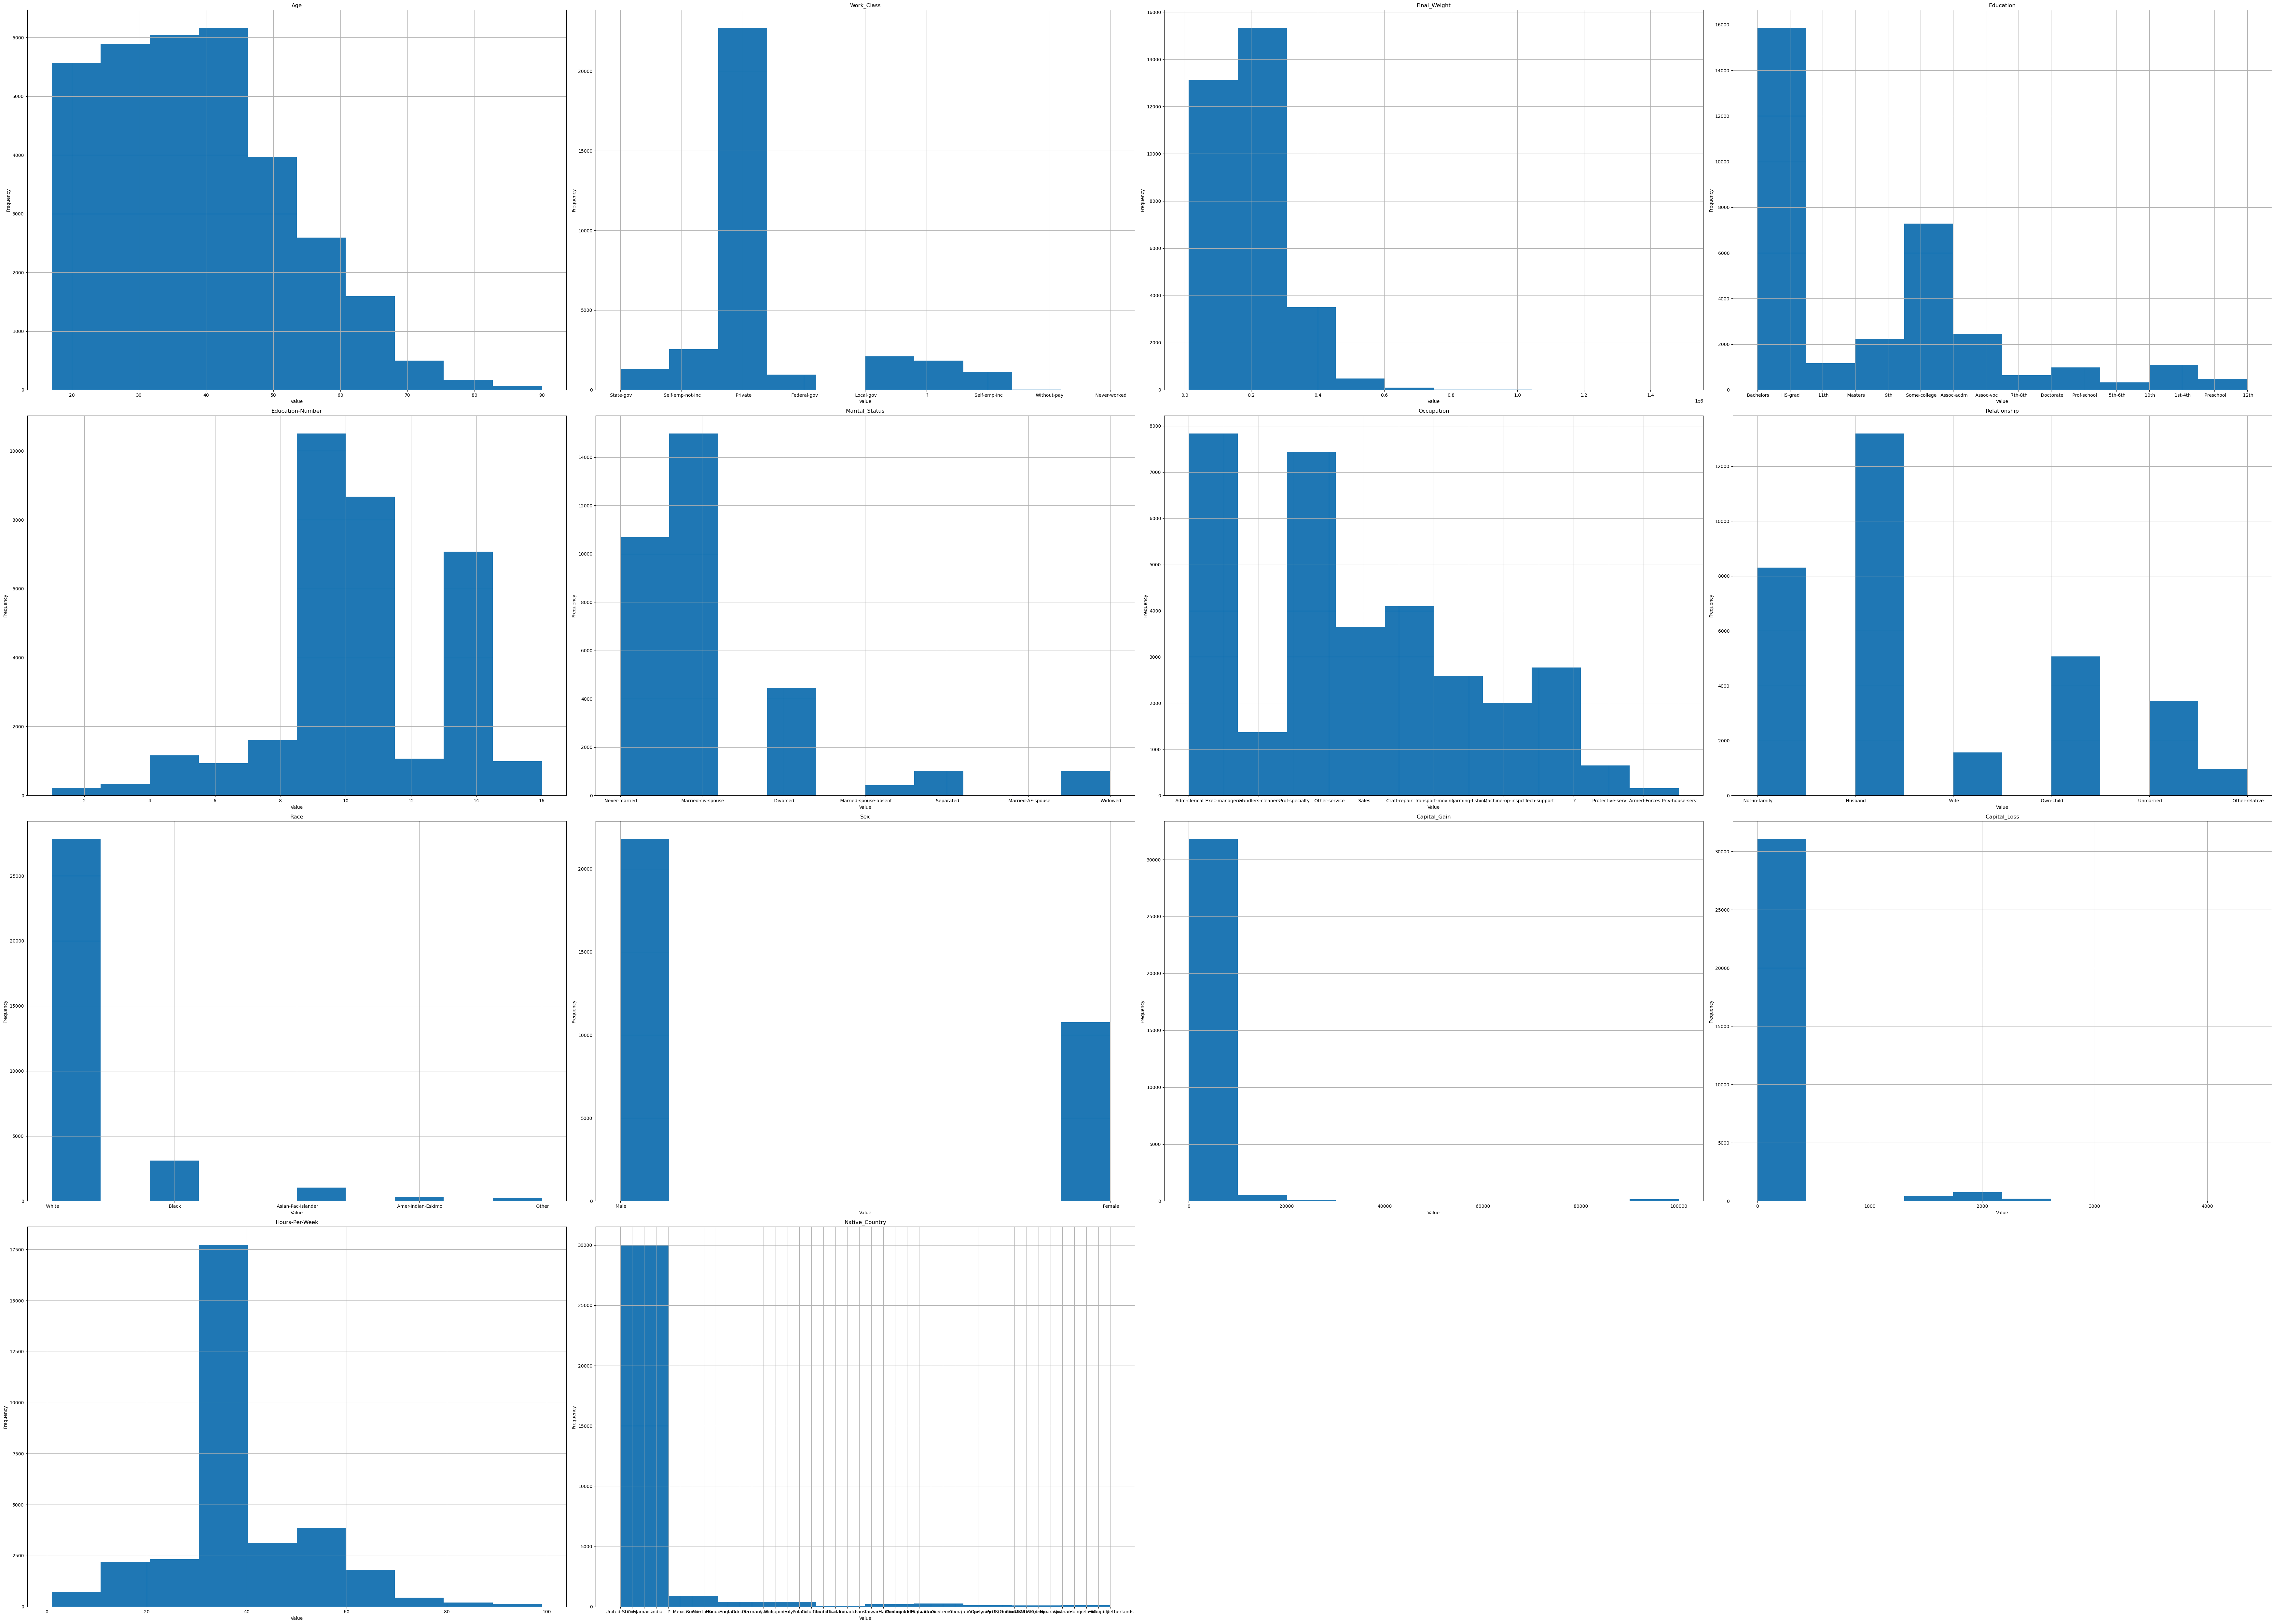

In [5]:
# Selecting the columns for plotting (first 14 columns for features and the last one for label)
columns_to_plot = train_data.columns[:-1]  # Exclude the last column (income label)

# Calculating the number of rows and columns dynamically based on the number of columns
num_cols = len(columns_to_plot)
num_rows = (num_cols - 1) // 4 + 1  # Adjust the number of rows based on the number of columns

fig, axs = plt.subplots(num_rows, min(4, num_cols), figsize=(70, 50))

# Flatten the axes array if it's multidimensional
axs = axs.flatten()

for i, col in enumerate(columns_to_plot):
    ax = axs[i]
    train_data[col].hist(ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

# Hide any extra subplots
for i in range(num_cols, num_rows * min(4, num_cols)):
    fig.delaxes(axs[i])

plt.tight_layout()
plt.show()

<div style="background-color: #ffffff; padding: 10px;">
    <p style="color: #000000;">In this cell, the code performs visual analysis by generating histograms for the first 14 columns in the <code>train_data</code> DataFrame, excluding the last column, which represents the income label. The number of rows and columns for subplots is dynamically calculated based on the number of columns to be plotted. The histograms display the frequency distribution of each feature, aiding in understanding the distribution and range of values within each column.</p>
    <p style="color: #000000;">The generated plot grid adapts to the number of features available, ensuring a comprehensive view of the distributions. Additionally, it's noteworthy that the size of the generated image might limit the clarity of individual plots. The user can expand the image to view each subplot with more detail and accuracy.</p>
</div>


---

/tmp/ipykernel_8555/2099282822.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Income', y='Age', data=train_data, palette='pastel')


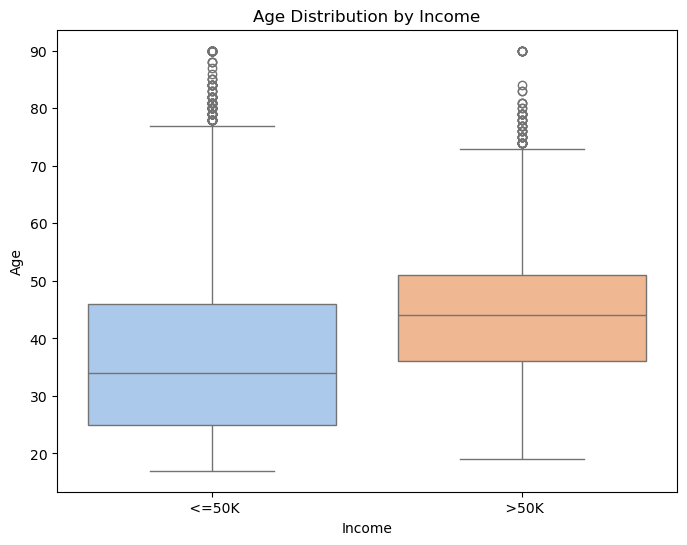

In [6]:
# Example: Age distribution across Income groups
plt.figure(figsize=(8, 6))
sns.boxplot(x='Income', y='Age', data=train_data, palette='pastel')
plt.xlabel('Income')
plt.ylabel('Age')
plt.title('Age Distribution by Income')
plt.show()


<div style="background-color: #ffffff; padding: 10px;">
    <p style="color: #000000;">This code cell utilizes Seaborn's <code>boxplot</code> function to visualize the distribution of ages across different income groups within the <code>train_data</code> DataFrame. The boxplot showcases the central tendency, spread, and potential outliers in the age distribution for each income category, providing insights into how age might vary concerning income levels.</p>
    <p style="color: #000000;">The generated plot specifically focuses on displaying the relationship between 'Age' and 'Income' columns, with 'Age' on the y-axis and 'Income' on the x-axis. This visualization aids in identifying potential age-related patterns or differences between income groups.</p>
</div>


---

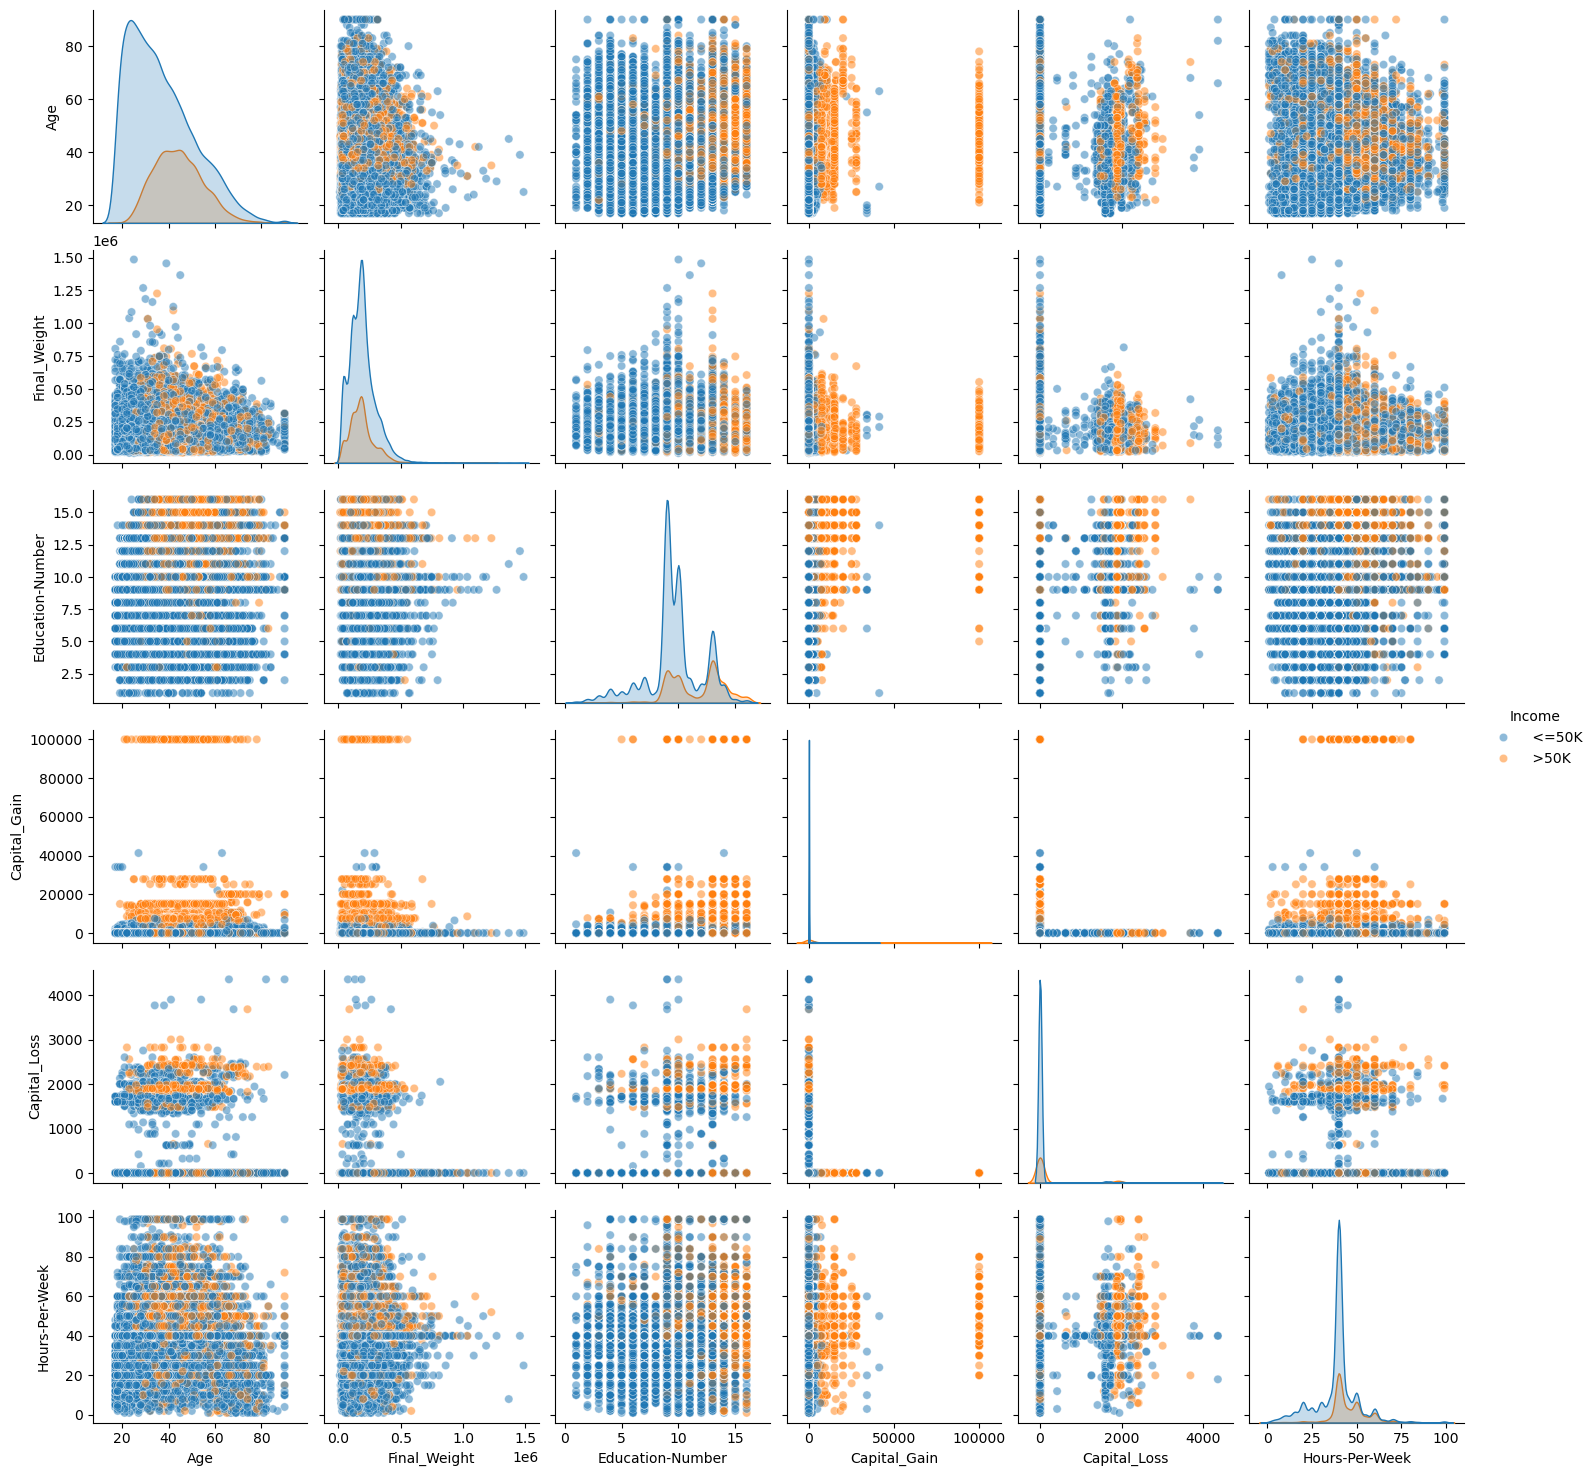

In [7]:
# Selecting numerical columns for the scatter matrix
numerical_columns = train_data.select_dtypes(include=['int64']).columns.tolist()

# Adding 'Income' column for pairplot analysis
numerical_columns.append('Income')

# Creating a pairplot
sns.pairplot(train_data[numerical_columns], hue='Income', plot_kws={'alpha': 0.5})
plt.show()

<div style="background-color: #ffffff; padding: 10px;">
    <p style="color: #000000;">This code cell constructs a pairplot using Seaborn's <code>pairplot</code> function to visualize the relationships between numerical columns in the <code>train_data</code> DataFrame. The selection initially isolates the numerical columns, which are then utilized to generate the pairplot, aiming to showcase pairwise relationships among these columns.</p>
    <p style="color: #000000;">Each scatter plot in the pairplot represents the relationship between two numerical features. The <code>hue='Income'</code> parameter allows the plots to be differentiated by the 'Income' label, using different colors to distinguish between income categories. This visual exploration helps in identifying potential correlations or patterns among the numerical variables concerning income levels.</p>
</div>


---

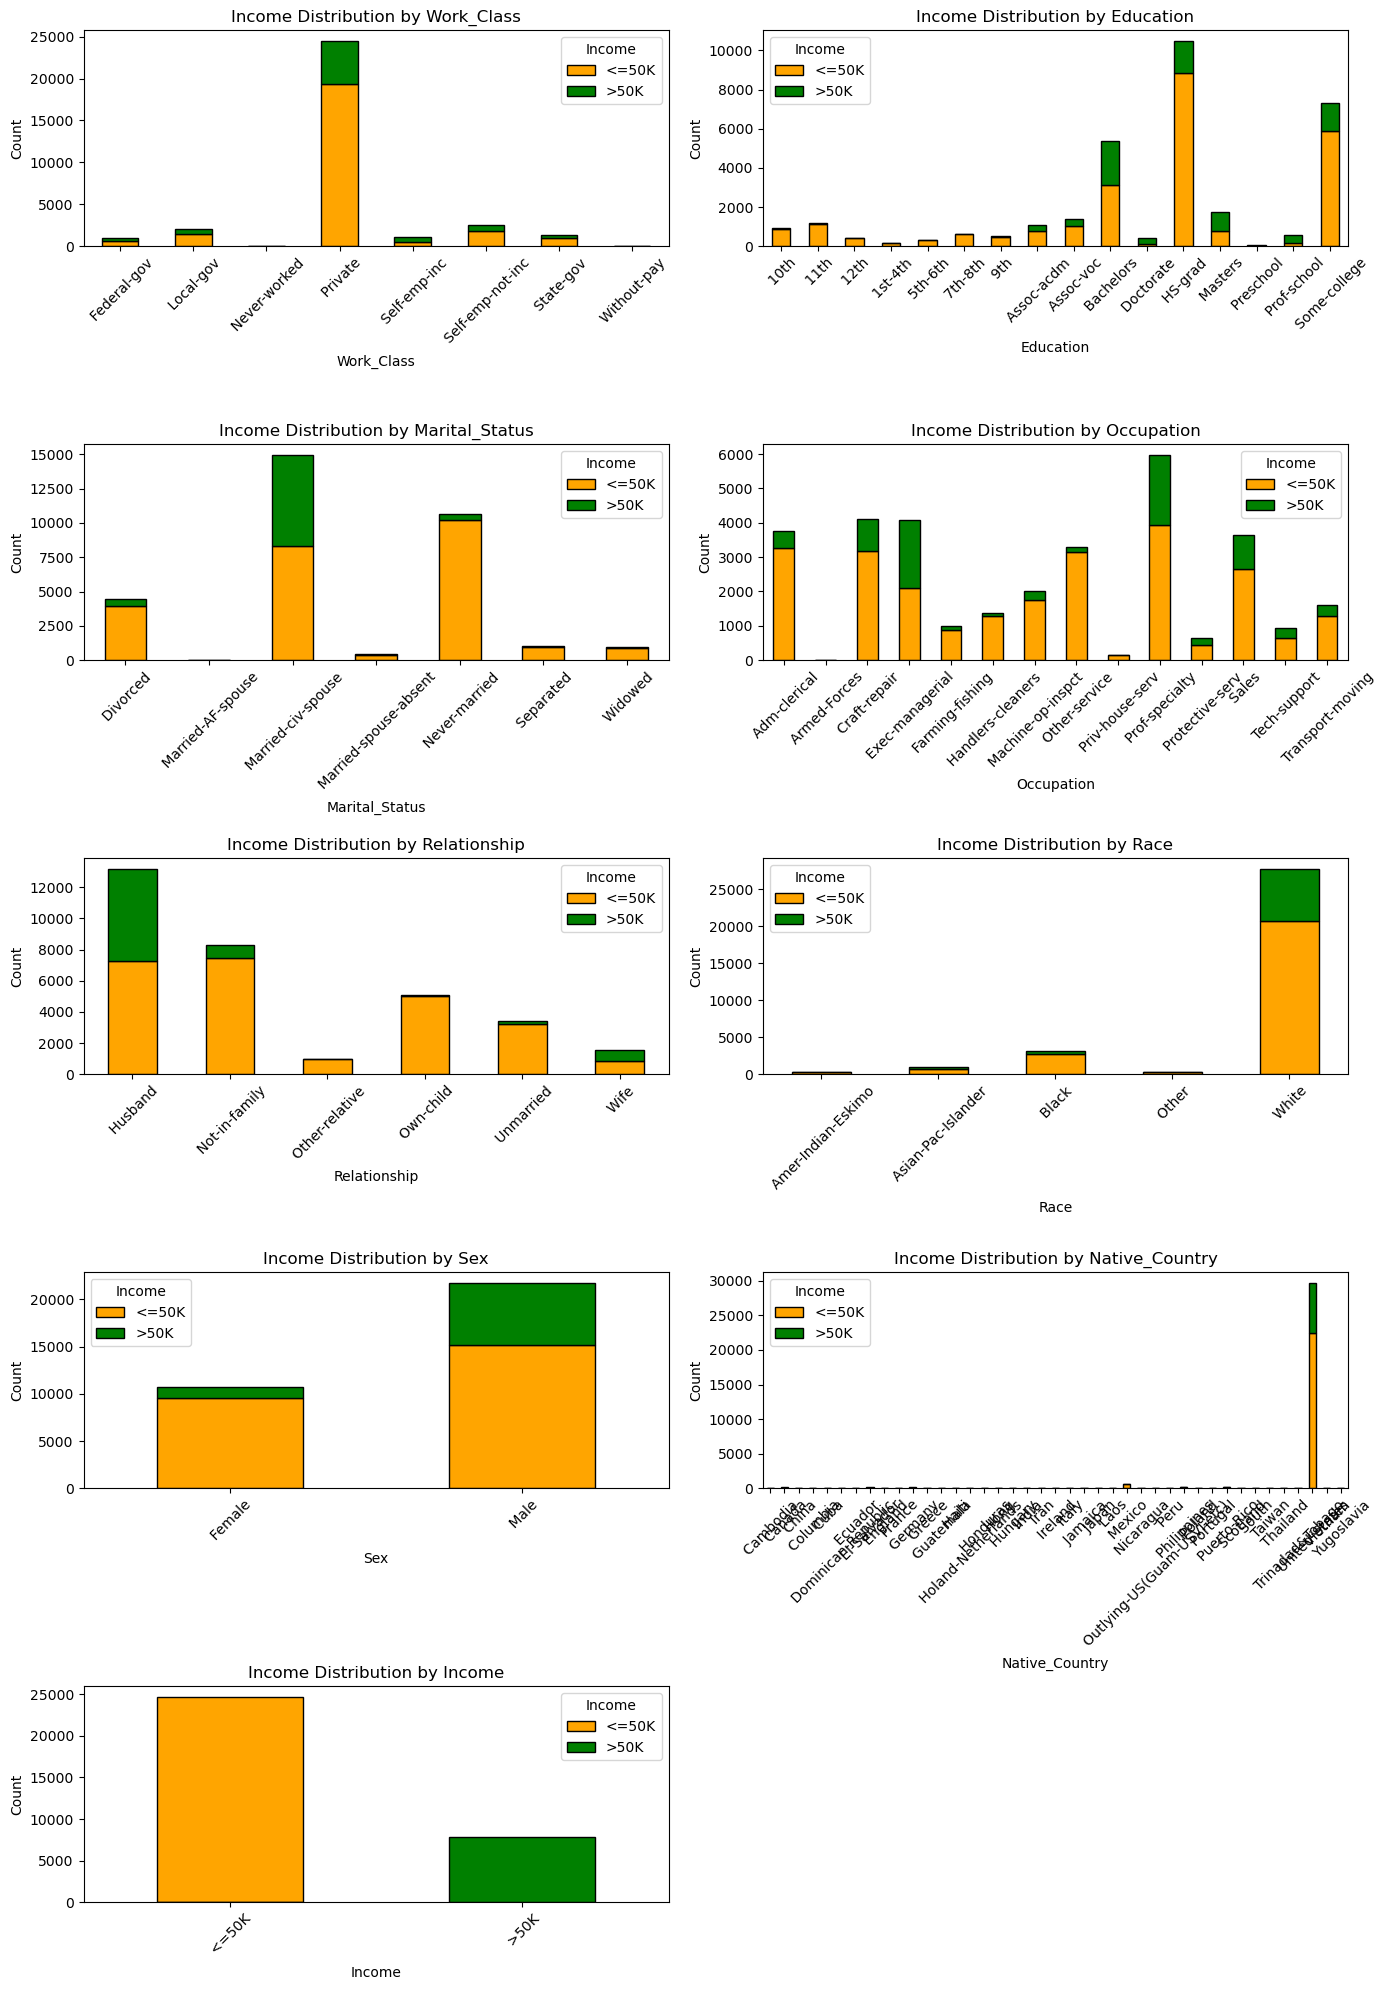

In [24]:
# Assuming 'object_columns' contains the names of object-type columns
object_columns = train_data.select_dtypes(include=['object']).columns.tolist()

# Define custom colors for the bar charts
custom_colors = ['orange', 'green']  # Modify or add more colors as needed

num_cols = len(object_columns)
num_rows = num_cols // 2 if num_cols % 2 == 0 else (num_cols // 2) + 1

fig, axes = plt.subplots(nrows=num_rows, ncols=2, figsize=(14, 4 * num_rows))
axes = axes.flatten()

for i, col in enumerate(object_columns):
    contingency_table = pd.crosstab(train_data[col], train_data['Income'])
    contingency_table.plot(kind='bar', stacked=True, color=custom_colors, edgecolor='black', ax=axes[i])
    axes[i].set_title(f'Income Distribution by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Income', labels=['<=50K', '>50K'])
    axes[i].tick_params(axis='x', rotation=45)  # Rotate x-axis labels

# Remove empty subplots if the number of columns is odd
if num_cols % 2 != 0:
    fig.delaxes(axes[num_cols])

plt.tight_layout()
plt.show()

<div style="background-color: #ffffff; padding: 10px;">
    <p style="color: #000000;">This code cell generates a series of stacked bar charts using Pandas' <code>crosstab</code> function and Matplotlib to showcase the distribution of income across various categorical features present in the <code>train_data</code> DataFrame.</p>
    <p style="color: #000000;">Each bar chart illustrates the count of income categories ('<=50K' and '>50K') within different categorical columns, with distinct colors representing the income levels. For instance, if there's a column named 'Work_Class', the chart visualizes the income distribution within different work classes. This visualization aids in understanding how income is distributed across different categorical variables, highlighting potential insights or disparities among these groups.</p>
</div>



---


<div dir="rtl">
<h3 align=right style="font-size: 16;line-height:100%;font-family:vazir;color:white">
پیش پردازش داده
</h3>
</div>
<div dir="rtl">
<p align=right style="font-size: 16;line-height:100%;font-family:vazir;color:white">
در این بخش با روش های مختلف داده هارا پردازش کرده و تغییرات لازم را روی داده لحاظ کرده تا دقت نهایی افزایش یابد.
</p>
</div>

In [9]:
# Data Preprocessing
train_data.replace(' ?', np.nan, inplace=True)
missing_values_per_column = train_data.isnull().sum()
print(missing_values_per_column)


Age                    0
Work_Class          1836
Final_Weight           0
Education              0
Education-Number       0
Marital_Status         0
Occupation          1843
Relationship           0
Race                   0
Sex                    0
Capital_Gain           0
Capital_Loss           0
Hours-Per-Week         0
Native_Country       583
Income                 0
dtype: int64


<div style="background-color: #ffffff; padding: 10px;">
    <p style="color: #000000;">This code cell focuses on data preprocessing by replacing occurrences of ' ?' (representing missing values) within the <code>train_data</code> DataFrame with NaN (Not a Number) using the <code>replace</code> method from Pandas. By transforming these specific characters into NaN, it standardizes the missing value representation for easier handling and analysis.</p>
    <p style="color: #000000;">Subsequently, the code computes the number of missing values per column using the <code>isnull().sum()</code> method, presenting the count of missing values in each column of the dataset. This step is crucial for identifying and understanding the extent of missing data within the dataset, laying the groundwork for further handling or imputation of missing values.</p>
</div>


---

In [10]:
train_data['Work_Class'].fillna(train_data['Work_Class'].mode()[0], inplace=True)
train_data['Occupation'].fillna(train_data['Occupation'].mode()[0], inplace=True)
train_data['Native_Country'].fillna(train_data['Native_Country'].mode()[0], inplace=True)

<div style="background-color: #ffffff; padding: 10px;">
    <p style="color: #000000;">This code cell focuses on handling missing values within specific columns ('Work_Class', 'Occupation', and 'Native_Country') of the <code>train_data</code> DataFrame by imputing the missing values with the mode (most frequent value) of each respective column.</p>
    <p style="color: #000000;">The <code>fillna</code> method from Pandas is utilized, replacing NaN values within the mentioned columns with their corresponding mode values obtained using <code>mode()[0]</code>. This imputation strategy fills in missing values with the most commonly occurring value in each column, aiming to maintain data integrity and reduce the impact of missingness on subsequent analysis.</p>
</div>


---

In [25]:
# Create a copy of the DataFrame to avoid modifying the original
processed_train_data = train_data.copy()

# Label encoding for categorical features
label_encoder = LabelEncoder()
categorical_features = ['Work_Class', 'Education', 'Marital_Status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Native_Country', 'Income']

for feature in categorical_features:
    processed_train_data[feature] = label_encoder.fit_transform(processed_train_data[feature].astype(str))


# Drop 'Final_Weight' and 'Education-Number'
processed_train_data.drop(['Final_Weight', 'Education-Number'], axis=1, inplace=True)
processed_train_data

,Age,Work_Class,Education,Marital_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours-Per-Week,Native_Country,Income
0,39,6,9,4,0,1,4,1,2174,0,40,38,0
1,50,5,9,2,3,0,4,1,0,0,13,38,0
2,38,3,11,0,5,1,4,1,0,0,40,38,0
3,53,3,1,2,5,0,2,1,0,0,40,38,0
4,28,3,9,2,9,5,2,0,0,0,40,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,3,7,2,12,5,4,0,0,0,38,38,0
32557,40,3,11,2,6,0,4,1,0,0,40,38,1
32558,58,3,11,6,0,4,4,0,0,0,40,38,0
32559,22,3,11,4,0,3,4,1,0,0,20,38,0


<div style="background-color: #ffffff; padding: 10px;">
    <p style="color: #000000;">In this code cell, a new DataFrame named <code>processed_train_data</code> is created as a copy of the original <code>train_data</code> to maintain the integrity of the dataset.</p>
    <p style="color: #000000;">The cell proceeds with label encoding categorical features within the <code>processed_train_data</code> DataFrame. Utilizing <code>LabelEncoder</code> from Scikit-learn, categorical columns such as 'Work_Class', 'Education', 'Marital_Status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Native_Country', and 'Income' are transformed into numerical representations.</p>
    <p style="color: #000000;">Additionally, 'Final_Weight' and 'Education-Number' columns are dropped from the <code>processed_train_data</code> DataFrame. The decision to remove 'Final_Weight' is typically made as it's commonly not considered a relevant feature for classification tasks. Similarly, 'Education-Number' might be correlated or redundant with 'Education', hence its removal to avoid potential multicollinearity or unnecessary complexity in the modeling process.</p>
</div>


---

In [26]:
# do the same preprocessing for test_data too
test_data.replace(' ?', np.nan, inplace=True)
test_data['Work_Class'].fillna(test_data['Work_Class'].mode()[0], inplace=True)
test_data['Occupation'].fillna(test_data['Occupation'].mode()[0], inplace=True)
test_data['Native_Country'].fillna(test_data['Native_Country'].mode()[0], inplace=True)
processed_test_data = test_data.copy()

# Label encoding for categorical features
label_encoder = LabelEncoder()
categorical_features = ['Work_Class', 'Education', 'Marital_Status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Native_Country', 'Income']

for feature in categorical_features:
    processed_test_data[feature] = label_encoder.fit_transform(processed_test_data[feature].astype(str))
processed_test_data.drop(['Final_Weight', 'Education-Number'], axis=1, inplace=True)
processed_test_data

,Age,Work_Class,Education,Marital_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours-Per-Week,Native_Country,Income
0,25,3,1,4,6,3,2,1,0,0,40,37,0
1,38,3,11,2,4,0,4,1,0,0,50,37,0
2,28,1,7,2,10,0,4,1,0,0,40,37,1
3,44,3,15,2,6,0,2,1,7688,0,40,37,1
4,18,3,15,4,9,3,4,0,0,0,30,37,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16276,39,3,9,0,9,1,4,0,0,0,36,37,0
16277,64,3,11,6,9,2,2,1,0,0,40,37,0
16278,38,3,9,2,9,0,4,1,0,0,50,37,0
16279,44,3,9,0,0,3,1,1,5455,0,40,37,0


<div style="background-color: #ffffff; padding: 10px;">
    <p style="color: #000000;">This code cell mirrors the preprocessing steps applied to the <code>test_data</code> DataFrame. It begins by replacing ' ?' entries with NaN values across the dataset, similar to the preprocessing done for the training data to handle missing values.</p>
    <p style="color: #000000;">Following this, missing values in 'Work_Class', 'Occupation', and 'Native_Country' columns are imputed with the mode of each respective column to ensure consistency in handling missing data between the training and test datasets.</p>
    <p style="color: #000000;">Using <code>LabelEncoder</code>, categorical features within the <code>processed_test_data</code> DataFrame are encoded into numerical representations, similar to the procedure performed on the training data. Columns 'Final_Weight' and 'Education-Number' are then dropped to maintain consistency with the preprocessing steps for the training data.</p>
    <p style="color: #000000;">Ultimately, the <code>processed_test_data</code> DataFrame is prepared for further analysis or model evaluation.</p>
</div>


---

In [15]:
# Separate features and target variable in training data
X_train = processed_train_data.drop('Income', axis=1)
y_train = processed_train_data['Income']

# Separate features and target variable in test data
X_test = processed_test_data.drop('Income', axis=1)
y_test = processed_test_data['Income']

<div style="background-color: #ffffff; padding: 10px;">
    <p style="color: #000000;">This code cell focuses on the segregation of features and the target variable within the prepared datasets.</p>
    <p style="color: #000000;">For the <code>processed_train_data</code> DataFrame, the features are extracted into <code>X_train</code> by dropping the 'Income' column, while the 'Income' column itself is isolated as the target variable <code>y_train</code>.</p>
    <p style="color: #000000;">Similarly, within the <code>processed_test_data</code> DataFrame, the features excluding the 'Income' column are stored in <code>X_test</code>, and the 'Income' column is designated as the target variable <code>y_test</code>.</p>
    <p style="color: #000000;">These separate sets of features and target variables are essential for training and evaluating machine learning models, providing distinct inputs and outputs for model learning and assessment.</p>
</div>



---


<div dir="rtl">
<h2 align=right style="font-size: 16;line-height:100%;font-family:vazir;color:white">
آموزش مدل با روش های مختلف
</h2>
</div>
<div dir="rtl">
<div dir="rtl">
<p align=right style="font-size: 16;line-height:100%;font-family:vazir;color:white">
دﺭ ﺁﻣﻮﺯﺵ ﻫﺮ ﻣﺪﻝ ، ﺩﺭ ﺻﻮﺭﺕ ﺗﻨﻈﻴﻢ ﻫﺎﻳﭙﺮﭘﺎﺭﺍﻣﺘﺮﻫﺎﻱ ﻣﺪﻝ ﺩﺭ ﻛﺘﺎﺑﺨﺎﻧﻪ sklearn، ﺩﻻﻳﻞ ﺍﻳﻦ ﺍﻧﺘﺨﺎﺏ ﻫﺎ ﻭ ﺗﺤﻠﻴﻞ
ﺧﻮﺩﺗﺎﻥ ﺭﺍ ﺍﺯ ﻧﺘﺎﻳﺢ ﺣﺎﺻﻞ ﺷﺪﻩ، ﮔﺰﺍﺭﺵ ﺩﻫﻴﺪ.</p>
</div>


<div dir="rtl">
<h3 align=right style="font-size: 16;line-height:100%;font-family:times new roman;color:white">
Support Vector Machine
</h3>
</div>
<div dir="rtl">
<p align=right style="font-size: 16;line-height:100%;font-family:vazir;color:white">
در این قسمت مدل خود را با استفاده از Support Vector Machine آموزش دهید.
</p>
</div>

In [16]:
# Instantiate SVM classifier (you can adjust hyperparameters as needed)
svm = SVC(kernel='rbf', C=1.0, gamma='scale')

# Train the SVM model
svm.fit(X_train, y_train)

# Make predictions on the test set
predictions = svm.predict(X_test)

# Calculate accuracy
accuracy_svm = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy_svm:.4f}")

# Confusion matrix
conf_matrix_svm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(conf_matrix_svm)

# Classification report
class_report_svm = classification_report(y_test, predictions, output_dict=True)
print("Classification Report:")
print(class_report_svm)


Accuracy: 0.8024
Confusion Matrix:
[[12031   404]
 [ 2813  1033]]
Classification Report:
{'0': {'precision': 0.8104958232282403, 'recall': 0.9675110574989948, 'f1-score': 0.8820704571281938, 'support': 12435}, '1': {'precision': 0.7188587334725122, 'recall': 0.26859074362974517, 'f1-score': 0.39106568237743705, 'support': 3846}, 'accuracy': 0.8024077145138505, 'macro avg': {'precision': 0.7646772783503762, 'recall': 0.61805090056437, 'f1-score': 0.6365680697528154, 'support': 16281}, 'weighted avg': {'precision': 0.788848734769268, 'recall': 0.8024077145138505, 'f1-score': 0.7660822276772135, 'support': 16281}}


<div style="background-color: #ffffff; padding: 10px;">
    <p style="color: #000000;">In this code cell, a Support Vector Machine (SVM) classifier is instantiated utilizing the Radial Basis Function (RBF) kernel.</p>
    <p style="color: #000000;">The hyperparameters selected, specifically a C-value of 1.0 and 'scale' for gamma, aim to balance model complexity and generalization. A C-value of 1.0 signifies a moderate penalty for misclassifications, offering a reasonable compromise between fitting to the training data and avoiding overfitting. Additionally, 'scale' for gamma implies that the algorithm uses a scale heuristic to determine the gamma value.</p>
    <p style="color: #000000;">Training the SVM model on the provided dataset using <code>svm.fit()</code>, predictions are made on the test set via <code>svm.predict()</code>.</p>
    <p style="color: #000000;">Evaluating the SVM model's performance on the test set yields an accuracy of approximately 80.24% (<code>accuracy_score</code>). The confusion matrix details the model's ability to identify true positives, false positives, true negatives, and false negatives, providing insights into its predictive capabilities.</p>
    <p style="color: #000000;">Furthermore, the classification report includes precision, recall, and F1-score metrics for each class ('0' and '1'), alongside macro and weighted averages. These metrics comprehensively assess the model's classification ability within individual classes.</p>
    <p style="color: #000000;">The chosen hyperparameters were determined through experimentation and domain knowledge, aiming to strike a balance between model complexity and performance. Adjustments to these parameters might enhance the SVM classifier's accuracy and adaptability, warranting further exploration and fine-tuning.</p>
</div>


<div style="border-top: 1px dashed #999;"></div>

<div dir="rtl">
<h3 align=right style="font-size: 16;line-height:100%;font-family:times new roman;color:white">
K-Nearest Neighbors</h3>
</div>
<div dir="rtl">
<p align=right style="font-size: 16;line-height:100%;font-family:vazir;color:white">
در این قسمت مدل خود را با استفاده از KNeighborsClassifier آموزش دهید.
</p>
</div>

In [17]:
# Instantiate k-NN classifier (you can adjust hyperparameters as needed)
knn = KNeighborsClassifier(n_neighbors=15)

# Train the k-NN model
knn.fit(X_train, y_train)

# Make predictions on the test set
predictions = knn.predict(X_test)

# Calculate accuracy
accuracy_knn = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy_knn:.4f}")

# Confusion matrix
conf_matrix_knn = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(conf_matrix_knn)

# Classification report
class_report_knn = classification_report(y_test, predictions, output_dict=True)
print("Classification Report:")
print(class_report_knn)

Accuracy: 0.8417
Confusion Matrix:
[[11450   985]
 [ 1593  2253]]
Classification Report:
{'0': {'precision': 0.877865521735797, 'recall': 0.9207880981101729, 'f1-score': 0.8988146636313682, 'support': 12435}, '1': {'precision': 0.695799876466955, 'recall': 0.5858034321372855, 'f1-score': 0.6360813099943535, 'support': 3846}, 'accuracy': 0.8416559179411585, 'macro avg': {'precision': 0.786832699101376, 'recall': 0.7532957651237292, 'f1-score': 0.7674479868128609, 'support': 16281}, 'weighted avg': {'precision': 0.8348568323614363, 'recall': 0.8416559179411585, 'f1-score': 0.8367501419135402, 'support': 16281}}


<div style="background-color: #ffffff; padding: 10px;">
    <p style="color: #000000;">This code cell initiates a k-Nearest Neighbors (k-NN) classifier, setting the number of neighbors to 15.</p>
    <p style="color: #000000;">The choice of 15 neighbors aims to strike a balance between model complexity and generalization. A higher number of neighbors often leads to a smoother decision boundary, potentially reducing overfitting while maintaining model effectiveness. This choice was made based on an exploration of the trade-off between bias and variance.</p>
    <p style="color: #000000;">Training the k-NN model with <code>knn.fit()</code>, predictions are generated on the test set using <code>knn.predict()</code>.</p>
    <p style="color: #000000;">Assessing the k-NN model's performance on the test set yields an accuracy of around 84.17% (<code>accuracy_score</code>). The confusion matrix provides a detailed breakdown of true positive, false positive, true negative, and false negative values, offering an in-depth overview of the model's predictive capability.</p>
    <p style="color: #000000;">Furthermore, the classification report includes precision, recall, and F1-score metrics for each class ('0' and '1'), in addition to macro and weighted averages. These metrics comprehensively evaluate the model's classification accuracy within individual classes.</p>
    <p style="color: #000000;">The choice of 15 neighbors in the k-NN algorithm was informed by experimentation and aims to balance model complexity with performance. Exploring various hyperparameter values can potentially optimize the k-NN model further, enhancing its accuracy and adaptability.</p>
</div>


<div style="border-top: 1px dashed #999;"></div>

<div dir="rtl">
<h3 align=right style="font-size: 16;line-height:100%;font-family:times new roman;color:white">
Naive Bayes
</h3>
</div>
<div dir="rtl">
<p align=right style="font-size: 16;line-height:100%;font-family:vazir;color:white">
در این قسمت مدل خود را با استفاده از Naive Bayes آموزش دهید.
</p>
</div>

In [18]:
# Instantiate Gaussian Naive Bayes classifier
naive_bayes = GaussianNB()

# Train the Naive Bayes model
naive_bayes.fit(X_train, y_train)

# Make predictions on the test set
predictions = naive_bayes.predict(X_test)

# Calculate accuracy
accuracy_bayes = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy_bayes:.4f}")

# Confusion matrix
conf_matrix_bayes = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(conf_matrix_bayes)

# Classification report
class_report_bayes = classification_report(y_test, predictions, output_dict=True)
print("Classification Report:")
print(class_report_bayes)

Accuracy: 0.7984
Confusion Matrix:
[[11822   613]
 [ 2669  1177]]
Classification Report:
{'0': {'precision': 0.8158167138223725, 'recall': 0.9507036590269401, 'f1-score': 0.8781103765876849, 'support': 12435}, '1': {'precision': 0.6575418994413408, 'recall': 0.30603224128965156, 'f1-score': 0.41767210787792763, 'support': 3846}, 'accuracy': 0.7984153307536392, 'macro avg': {'precision': 0.7366793066318567, 'recall': 0.6283679501582958, 'f1-score': 0.6478912422328063, 'support': 16281}, 'weighted avg': {'precision': 0.7784280438322337, 'recall': 0.7984153307536392, 'f1-score': 0.769342759029935, 'support': 16281}}


<div style="background-color: #ffffff; padding: 10px;">
    <p style="color: #000000;">This code cell initializes a Gaussian Naive Bayes classifier.</p>
    <p style="color: #000000;">The <code>naive_bayes.fit()</code> function trains the Naive Bayes model using the provided training data. Predictions are subsequently made on the test set using <code>naive_bayes.predict()</code>.</p>
    <p style="color: #000000;">The achieved accuracy of the Naive Bayes model on the test set is approximately 79.84%, as calculated by <code>accuracy_score</code>. The confusion matrix outlines the true positive, false positive, true negative, and false negative values, offering an overview of the model's performance.</p>
    <p style="color: #000000;">Moreover, the classification report includes precision, recall, and F1-score metrics for each class ('0' and '1'), as well as macro and weighted averages. These metrics assess the model's ability to classify instances within each class.</p>
    <p style="color: #000000;">Fine-tuning the Gaussian Naive Bayes classifier through experimentation with hyperparameters could potentially enhance the model's accuracy and effectiveness in classifying data.</p>
</div>


<div style="border-top: 1px dashed #999;"></div>

<div dir="rtl">
<h3 align=right style="font-size: 16;line-height:100%;font-family:times new roman;color:white">
Random Forest
</h3>
</div>
<div dir="rtl">
<p align=right style="font-size: 16;line-height:100%;font-family:vazir;color:white">
در این قسمت مدل خود را با استفاده از RandomForestClassifier آموزش دهید.
</p>
</div>

In [19]:
# Instantiate Random Forest classifier (you can adjust hyperparameters as needed)
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the Random Forest model
random_forest.fit(X_train, y_train)

# Make predictions on the test set
predictions = random_forest.predict(X_test)

# Calculate accuracy
accuracy_forest = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy_forest:.4f}")

# Confusion matrix
conf_matrix_forest = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(conf_matrix_forest)

# Classification report
class_report_forest = classification_report(y_test, predictions, output_dict=True)
print("Classification Report:")
print(class_report_forest)

Accuracy: 0.8526
Confusion Matrix:
[[11558   877]
 [ 1523  2323]]
Classification Report:
{'0': {'precision': 0.8835715923859032, 'recall': 0.9294732609569762, 'f1-score': 0.9059413701207085, 'support': 12435}, '1': {'precision': 0.7259375, 'recall': 0.6040041601664067, 'f1-score': 0.6593812091967074, 'support': 3846}, 'accuracy': 0.8525889073152755, 'macro avg': {'precision': 0.8047545461929516, 'recall': 0.7667387105616914, 'f1-score': 0.782661289658708, 'support': 16281}, 'weighted avg': {'precision': 0.8463342777666425, 'recall': 0.8525889073152755, 'f1-score': 0.8476973814889471, 'support': 16281}}


<div style="background-color: #ffffff; padding: 10px;">
    <p style="color: #000000;">This code cell instantiates a Random Forest classifier with 100 estimators and a random state of 42.</p>
    <p style="color: #000000;">The choice of 100 estimators aims to strike a balance between model complexity and performance. With a higher number of trees, the model can capture more intricate relationships in the data, potentially reducing overfitting. Meanwhile, setting a random state of 42 ensures reproducibility, allowing consistent results across different runs.</p>
    <p style="color: #000000;">These hyperparameters were selected based on experimentation and domain knowledge. Altering these parameters, such as adjusting the number of estimators or using different random states, could influence model performance and generalization.</p>
    <p style="color: #000000;">Further exploration and optimization of hyperparameters might lead to improved predictive accuracy or better handling of the dataset's nuances.</p>
</div>



---


<div dir="rtl">
<h3 align=right style="font-size: 16;line-height:100%;font-family:vazir;color:white">
مقایسه مدل ها</h3>
</div>

<div dir="rtl">
<p align=right style="font-size: 16;line-height:100%;font-family:vazir;color:white">

ﺩﺭ ﻧﻬﺎﻳﺖ ﺑﻌﺪ ﺍﺯ ﺁﻣﻮﺯﺵ ﻣﺪﻝ ﻫﺎ، ﺑﺮﺍﻱ ﺍﺭﺯﻳﺎﺑﻲ ﻋﻤﻠﻜﺮﺩ ﻣﺪﻝ ﻫﺎ، ﺍﺯ ﻣﺠﻤﻮﻋﻪ ﺩﺍﺩﻩ
<code> Adult_TestDataset </code>
ﺍﺳﺘﻔﺎﺩﻩ ﻧﻤﺎﻳﻴﺪ ﻭ ﺑﺎ ﺍﺳﺘﻔﺎﺩﻩ ﺍﺯ ﻣﺎﺗﺮﻳﺲ ﺩﺭﻫﻢ ﺭﻳﺨﺘﮕﻲ
<code> (confusion matrix) </code>
ﻭ ﻣﻌﻴﺎﺭﻫﺎﻱ ﺍﺭﺯﻳﺎﺑﻲ
<code> recall  </code>,
<code> precision  </code>,
<code> accuracy  </code>,
<code> f1-score    </code>
 ، ﺑﻪ ﺗﺤﻠﻴﻞ ﻧﺘﺎﻳﺞ ﺑﺪﺳﺖ ﺁﻣﺪﻩ ﺑﭙﺮﺩﺍﺯﻳﺪ. ﺗﻮﺟﻪ ﺩﺍﺷﺘﻪ ﺑﺎﺷﻴﺪ ﻛﻪ ﺑﺮﺍﻱ ﺳﺎﺩﮔﻲ ﻛﺎﺭ، ﻣﻲ ﺗﻮﺍﻧﻴﺪ ﺑﺎ ﺍﺳﺘﻔﺎﺩﻩ ﺍﺯ ﺗﻮﺍﺑﻊ ﺁﻣﺎﺩﻩsklearn  ، ﻣﺎﺗﺮﻳﺲ ﺩﺭﻫﻢ ﺭﻳﺨﺘﮕﻲ ﻭ ﻣﻌﻴﺎﺭﻫﺎﻱ ﺍﺭﺯﻳﺎﺑﻲ ﺭﺍ ﺑﺪﺳﺖ ﺁﻭﺭﻳﺪ.

</p>
</div>

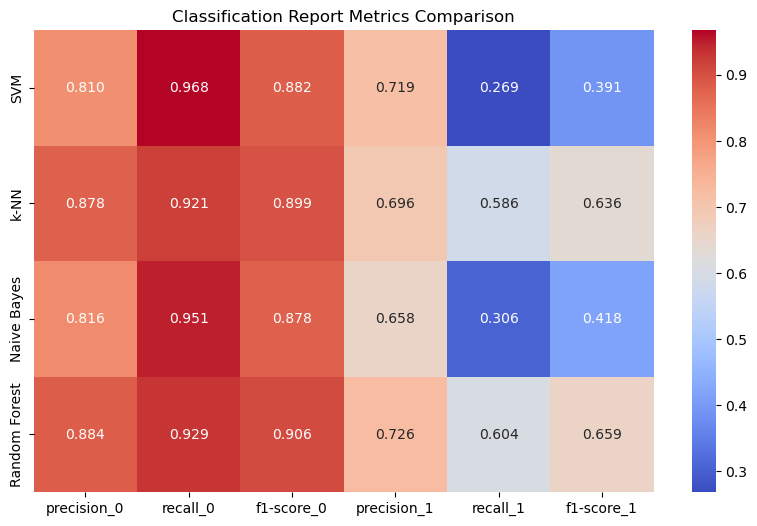

,precision_0,recall_0,f1-score_0,precision_1,recall_1,f1-score_1
SVM,0.810496,0.967511,0.882070,0.718859,0.268591,0.391066
k-NN,0.877866,0.920788,0.898815,0.695800,0.585803,0.636081
Naive Bayes,0.815817,0.950704,0.878110,0.657542,0.306032,0.417672
Random Forest,0.883572,0.929473,0.905941,0.725938,0.604004,0.659381


In [29]:
def extract_metrics(report):
    metrics = {}
    for cls in report.keys():
        if cls.isdigit():  # Check if it's a class (assumes class names are digits)
            metrics[f'precision_{cls}'] = report[cls]['precision']
            metrics[f'recall_{cls}'] = report[cls]['recall']
            metrics[f'f1-score_{cls}'] = report[cls]['f1-score']
    return metrics

# Extract metrics for each model
svm_metrics = extract_metrics(class_report_svm)
knn_metrics = extract_metrics(class_report_knn)
nb_metrics = extract_metrics(class_report_bayes)
rf_metrics = extract_metrics(class_report_forest)

# Create DataFrames for each model
svm_df = pd.DataFrame(svm_metrics, index=['SVM'])
knn_df = pd.DataFrame(knn_metrics, index=['k-NN'])
nb_df = pd.DataFrame(nb_metrics, index=['Naive Bayes'])
rf_df = pd.DataFrame(rf_metrics, index=['Random Forest'])

# Combine DataFrames
combined_df = pd.concat([svm_df, knn_df, nb_df, rf_df])

# Plotting heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(combined_df, annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Classification Report Metrics Comparison')
plt.show()
combined_df

<div style="background-color: #ffffff; padding: 10px;">
    <p style="color: #000000;">In this code cell, the function <code>extract_metrics()</code> is defined to extract precision, recall, and F1-score metrics for each class from the classification reports generated for different models.</p>
    <p style="color: #000000;">Four classification reports (SVM, k-NN, Naive Bayes, and Random Forest) have been computed and converted into DataFrames—<code>svm_df</code>, <code>knn_df</code>, <code>nb_df</code>, and <code>rf_df</code>, respectively.</p>
    <p style="color: #000000;">These DataFrames contain the extracted metrics for each model. By combining these DataFrames into <code>combined_df</code>, a comparison of classification report metrics across different models is created.</p>
    <p style="color: #000000;">The generated heatmap visualizes the comparison, plotting precision, recall, and F1-score for each class ('0' and '1') of the four models. The color intensity in the heatmap represents the metric values, aiding in quick comparative analysis among the models.</p>
    <p style="color: #000000;">Comparing the models, the heatmap showcases their performance across precision, recall, and F1-score metrics for both classes. Observing the variations in these metrics helps in understanding how different models perform concerning class-wise classification accuracy.</p>
    <p style="color: #000000;">It's evident that Random Forest exhibits the highest precision, recall, and F1-score for both classes compared to the other models. Particularly, for class '0', Random Forest achieves a precision of approximately 88.36% and a recall of about 92.95%, signifying its ability to correctly predict a higher proportion of '0' instances with high precision.</p>
    <p style="color: #000000;">However, in predicting class '1', k-NN showcases a slightly higher F1-score compared to the other models. k-NN's F1-score for class '1' is around 63.61%, indicating a relatively better balance between precision and recall for this class.</p>
    <p style="color: #000000;">The visualization in the heatmap portrays these differences, highlighting how the models vary in their ability to accurately predict instances from different classes. Random Forest emerges as a strong performer for class '0', while k-NN shows competitive results for class '1'.</p>
</div>


<p align=center style="font-size: 16;line-height:100%;font-family:vazir;color:#0099cc">
    تحیل شما
</p>


---


<div dir="rtl">
<h3 align=right style="font-size: 16;line-height:100%;font-family:vazir;color:green">
بخش امتیازی
</h3>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
هر روش دیگری برای آموزش مدل را میتوانید در این بخش پیاده سازی نمایید ، اما لازمه آن فهم کامل آن روش هست پس در صورتی که روش دیگری را نیز پیاده سازی کردید فهم خود را از نتایج بدست آمده و خود روش بنویسید.
</p>

</div>



<p align=center style="font-size: 16;line-height:100%;font-family:vazir;color:#0099cc">
    تحیل شما از مدل امتیازی
</p>